In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("/content/hydrated_tweets.csv")

In [ ]:
# Before moving forward with a dataset:
# Confirm if country is not available
# Confirm if it was filtered on any search phrase
# Confirm if retweets are included, if yes, drop them
# Dropn NANs/impute as appropriate

In [ ]:
df[df.is_retweet == True]

,favorite_count,source,text,in_reply_to_screen_name,is_retweet,created_at,retweet_count,id_str


In [ ]:
df.tail()

,favorite_count,source,text,in_reply_to_screen_name,is_retweet,created_at,retweet_count,id_str
153749,1,Twitter for iPad,b'@theasscat I even get fooled sometimes. It\x...,theasscat,False,Mon Sep 07 04:03:13 +0000 2020,0,b'1302819689324670978'
153750,4,COVID-19MX,b'#ACTUALIZACI\xc3\x93N GLOBAL \xf0\x9f\x8c\x8...,NaN,False,Mon Sep 07 04:03:15 +0000 2020,2,b'1302819696652279814'
153751,0,erased16993361,b'#Covid19 bot \n#COVID19 last 5 days stats #U...,NaN,False,Mon Sep 07 04:03:06 +0000 2020,0,b'1302819659163500549'
153752,0,SocialFlow,"b""Coronavirus: What's open, what's closed in t...",NaN,False,Mon Sep 07 04:03:15 +0000 2020,0,b'1302819696178352131'
153753,0,Twitter for iPhone,b'@KellyannePolls is a very disgusting person ...,KellyannePolls,False,Mon Sep 07 04:03:13 +0000 2020,0,b'1302819688662134784'


In [ ]:
df.drop(columns=['id_str',"in_reply_to_screen_name","is_retweet"], inplace=True)

In [ ]:
df.head()

,favorite_count,source,text,created_at,retweet_count
0,1,Twitter for Android,"b""Don't believe it. https://t.co/VFfhPArn1a""",Sat Sep 03 04:09:04 +0000 2022,0
1,0,cmssocialservice,b'Surat records 11 new Covid-19 cases https://...,Sat Sep 03 04:06:03 +0000 2022,0
2,38,TweetDeck,b'Hennepin County will no longer require COVID...,Sat Sep 03 04:09:00 +0000 2022,6
3,2,Twitter Web App,"b'As of Sept 1, the capital has given over 63....",Sat Sep 03 04:08:52 +0000 2022,0
4,1,Twitter for Android,b'@KushThrough @BlazedRTs @rtsmallstreams @Rts...,Sat Sep 03 04:15:46 +0000 2022,3


In [ ]:
df.isna().sum().sum()

0

In [ ]:
# Function to Clean the Tweet.

import re
def clean_tweet(tweet):
    return ' '.join(re.sub('(\\\\n)|(b\"[^0-9A-Za-z A-Za-z0-9 \t]+)|(b\'[^0-9A-Za-z]+)|(b\"[A-Za-z0-9]+)|(b\'[A-Za-z0-9]+)|(b\'#[A-Za-z0-9]+)|(b\'@[A-Za-z0-9]+)|(\\\\x[A-Za-z0-9]+)|(@[A-Za-z0-9]+)|([^0-9A-Za-z \t])|(\w+:\/\/\S+)|([RT])', ' ', str(tweet).lower()).split())

# We only want the Text so :

# (@[A-Za-z0-9]+)   : Delete Anything like @hello @Letsupgrade etc
# ([^0-9A-Za-z \t]) : Delete everything other than text,number,space,tabspace
# (\w+:\/\/\S+)     : Delete https://
# ([RT]) : Remove "RT" from the tweet
# \xe2\x80\x9cguaran : Remove such tags
# b'@thedailybeast : Remove such words : SS - check if we can only remove the b' prefix instead of full word
# SS - Check if apostrophe can be retained eg: hadn't currently becomes hadn t

In [ ]:
# Call function to get Clean tweets
df["CleanTweet"] = df['text'].apply(lambda x : clean_tweet(x))
df.tail(20)

,favorite_count,source,text,created_at,retweet_count,CleanTweet
15651,0,Twitter Web App,"b""@MarcusOber @MarkJacob16 @ThankfulThinker Ye...",Sun Sep 04 02:03:29 +0000 2022,0,marcusober yeah i can t believe people lost th...
15652,0,Twitter Web App,b'@EatSleepMask I never had Covid-19',Sun Sep 04 02:00:40 +0000 2022,0,eatsleepmask i never had covid 19
15653,0,Twitter Web App,b'@ArmendarizDis16 You mean like he tried to e...,Sun Sep 04 02:02:59 +0000 2022,0,armendarizdis16 you mean like he tried to exto...
15654,0,Twitter for iPhone,b'@nachodezen @WNYOpenSchools And here you are...,Sun Sep 04 02:01:27 +0000 2022,0,nachodezen and here you are still responding w...
15655,1,Twitter for Android,b'@ABC @NBC @WEWS @CBS @CNN @MSNBC @CNBC @wkyc...,Sun Sep 04 02:01:05 +0000 2022,1,abc walgreens now offering appointme
15656,0,Twitter for Android,b'@OAICgov @CommBank @Qantas @Zurich LIED TO @...,Sun Sep 04 01:59:51 +0000 2022,0,oaicgov lied to connect all informed qantas ab...
15657,3,SocialNewsDesk,b'After years of sharp rises in home prices an...,Sun Sep 04 02:00:03 +0000 2022,1,years of sharp rises in home prices and stiff ...
15658,1,Twitter Web App,b'The psychological and physical damage being ...,Sun Sep 04 02:01:28 +0000 2022,1,psychological and physical damage being promot...
15659,12,True Anthem,b'While some parents are excitedly counting do...,Sun Sep 04 02:00:48 +0000 2022,5,some parents are excitedly counting down the f...
15660,0,Janindu's Bot,b'#COVID19 SL Update 2022-09-03 19:00:33\n61 n...,Sun Sep 04 02:00:04 +0000 2022,0,covid19 sl update 2022 09 03 19 00 33 61 new c...


In [ ]:
df[df.CleanTweet.eq("")]

,favorite_count,source,text,created_at,retweet_count,CleanTweet
284,0,Twitter for Android,b'Loading...\nhttps://t.co/KTyErlumSE',Sat Sep 03 04:35:31 +0000 2022,1,
380,1,Twitter for iPhone,b'Bruh\xe2\x80\xa6 https://t.co/sHo15KUg76',Sat Sep 03 04:41:56 +0000 2022,0,
420,7,Twitter for iPhone,b'WHAT? https://t.co/GYYkE8unrd',Sat Sep 03 04:49:20 +0000 2022,2,
482,4,Twitter Web App,b'Rubbish https://t.co/55tHIidTma',Sat Sep 03 05:04:51 +0000 2022,0,
662,7,Twitter for iPhone,b'Weaponized https://t.co/NLDiOrHy9x',Sat Sep 03 05:10:12 +0000 2022,2,
...,...,...,...,...,...,...
13731,0,twittbot.net,b'covid19',Sat Sep 03 22:41:31 +0000 2022,0,
14782,0,Twitter for Android,b'Stuck? https://t.co/IWbLxhoafj',Sun Sep 04 00:41:13 +0000 2022,0,
15073,0,Twitter for iPhone,b'What?!! https://t.co/9owiPzaSfp',Sun Sep 04 00:58:48 +0000 2022,0,
15238,0,Twitter for iPhone,b'This!! \xf0\x9f\x91\x87\xf0\x9f\x91\x87\xf0\...,Sun Sep 04 01:20:31 +0000 2022,0,


In [ ]:
df.drop(df.index[df.CleanTweet.eq("")], inplace=True)

In [ ]:
# Function to analyze Sentiment using TextBlob

from textblob import TextBlob
def analyze_sentiment(tweet):
    analysis = TextBlob(tweet)
    if analysis.sentiment.polarity > 0:
        return 'Positive'
    elif analysis.sentiment.polarity == 0:
        return 'Neutral'
    else:
        return 'Negative'

In [ ]:
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
def prepCloud(Topic_text,Topic):
    Topic = str(Topic).lower()
    Topic=' '.join(re.sub('([^0-9A-Za-z \t])', ' ', Topic).split())
    Topic = re.split("\s+",str(Topic))
    stopwords = set(STOPWORDS)
    stopwords.update(Topic) ### Add our topic in Stopwords, so it doesnt appear in wordClous
    ###
    text_new = " ".join([txt for txt in Topic_text.split() if txt not in stopwords])
    return text_new

In [ ]:
df.to_csv("TweetDataset.csv",index=False)

In [ ]:
# Call function to get the Sentiments

df["TextBlobSentiment"] = df["CleanTweet"].apply(lambda x : analyze_sentiment(x))
df.head(5)

,favorite_count,source,text,created_at,retweet_count,CleanTweet,Sentiment,TextBlobSentiment
0,1,Twitter for Android,"b""Don't believe it. https://t.co/VFfhPArn1a""",Sat Sep 03 04:09:04 +0000 2022,0,t believe it,Neutral,Neutral
1,0,cmssocialservice,b'Surat records 11 new Covid-19 cases https://...,Sat Sep 03 04:06:03 +0000 2022,0,records 11 new covid 19 cases,Positive,Positive
2,38,TweetDeck,b'Hennepin County will no longer require COVID...,Sat Sep 03 04:09:00 +0000 2022,6,county will no longer require covid 19 vaccine...,Neutral,Neutral
3,2,Twitter Web App,"b'As of Sept 1, the capital has given over 63....",Sat Sep 03 04:08:52 +0000 2022,0,of sept 1 the capital has given over 63 2 mill...,Neutral,Neutral
4,1,Twitter for Android,b'@KushThrough @BlazedRTs @rtsmallstreams @Rts...,Sat Sep 03 04:15:46 +0000 2022,3,kushthrough ww nowplaying x lilroyce her ev,Neutral,Neutral


In [ ]:
len(df)

15580

In [ ]:
# Check Summary of Random Record
n = 15300
print("Original tweet:\n",df['text'][n])
print()
print("Clean tweet:\n",df['CleanTweet'][n])
print()
print("Sentiment of the tweet:\n",df['Sentiment'][n])

Original tweet:
 b'As I parooz Twitter tonight; I\xe2\x80\x99m concern for the individuals who\xe2\x80\x99ve lived through 32+months of a pandemic who are s\xe2\x80\xa6 https://t.co/k65oi8X8qd'

Clean tweet:
 i parooz twitter tonight i concern for the individuals who lived through 32 months of a pandemic who are s

Sentiment of the tweet:
 Neutral


In [ ]:
# Overall Summary

print("Total Tweets Extracted Are {}".format(len(df.text)))
print("Total Positive Tweets are : {}".format(len(df[df["Sentiment"]=="Positive"])))
print("Total Negative Tweets are : {}".format(len(df[df["Sentiment"]=="Negative"])))
print("Total Neutral Tweets are : {}".format(len(df[df["Sentiment"]=="Neutral"])))

Total Tweets Extracted Are 15580
Total Positive Tweets are : 5458
Total Negative Tweets are : 2734
Total Neutral Tweets are : 7388


In [ ]:
df["Sentiment"].value_counts()

Neutral     7388
Positive    5458
Negative    2734
Name: Sentiment, dtype: int64

/usr/local/lib/python3.7/dist-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


Text(0.5, 1.0, 'Summary of Counts for Total tweets')

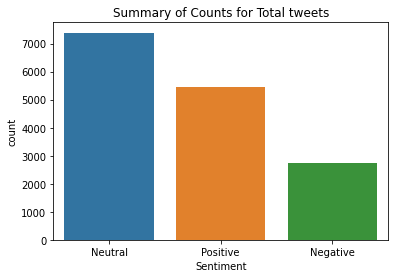

In [ ]:
#sns.countplot(df["Sentiment"],facecolor=(0, 0, 0, 0),linewidth=5,edgecolor=sns.color_palette("dark", 3))
sns.countplot(df["Sentiment"])
plt.title("Summary of Counts for Total tweets")

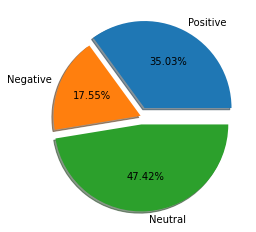

In [ ]:
# Piechart 

a=len(df[df["Sentiment"]=="Positive"])
b=len(df[df["Sentiment"]=="Negative"])
c=len(df[df["Sentiment"]=="Neutral"])
d=np.array([a,b,c])
explode = (0.1, 0.0, 0.1)
plt.pie(d,shadow=True,explode=explode,labels=["Positive","Negative","Neutral"],autopct='%1.2f%%');

In [ ]:
pip install vaderSentiment

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     |████████████████████████████████| 125 kB 4.1 MB/s 


In [ ]:
# Function to analyze Sentiment using Vader

#from textblob import TextBlob
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

def analyze_sentiment_vader(tweet):
    analyzer = SentimentIntensityAnalyzer()
    analysis = analyzer.polarity_scores(tweet)
    # decide sentiment as positive, negative and neutral
    if analysis['compound'] >= 0.05 :
        return "Positive"
    elif analysis['compound'] <= - 0.05 :
        return "Negative"
    else :
        return "Neutral"

In [ ]:
# Call function to get the Sentiments using Vader

df["VaderSentiment"] = df["CleanTweet"].apply(lambda x : analyze_sentiment_vader(x))

In [ ]:
df.tail(15)

In [ ]:
df.head()

,favorite_count,source,text,created_at,retweet_count,CleanTweet,Sentiment,TextBlobSentiment,VaderSentiment,FlairSentiment
0,1,Twitter for Android,"b""Don't believe it. https://t.co/VFfhPArn1a""",Sat Sep 03 04:09:04 +0000 2022,0,t believe it,Neutral,Neutral,Neutral,NEGATIVE
1,0,cmssocialservice,b'Surat records 11 new Covid-19 cases https://...,Sat Sep 03 04:06:03 +0000 2022,0,records 11 new covid 19 cases,Positive,Positive,Neutral,POSITIVE
2,38,TweetDeck,b'Hennepin County will no longer require COVID...,Sat Sep 03 04:09:00 +0000 2022,6,county will no longer require covid 19 vaccine...,Neutral,Neutral,Negative,POSITIVE
3,2,Twitter Web App,"b'As of Sept 1, the capital has given over 63....",Sat Sep 03 04:08:52 +0000 2022,0,of sept 1 the capital has given over 63 2 mill...,Neutral,Neutral,Neutral,NEGATIVE
4,1,Twitter for Android,b'@KushThrough @BlazedRTs @rtsmallstreams @Rts...,Sat Sep 03 04:15:46 +0000 2022,3,kushthrough ww nowplaying x lilroyce her ev,Neutral,Neutral,Neutral,POSITIVE


In [ ]:
df.to_csv("2020_Sep6_TextBlob-Vader-Flair-TweetSentimentDataset.csv",index=False)

In [ ]:
# Check Summary of Random Record for Vader
n = 15300
print("Original tweet:\n",df['text'][n])
print()
print("Clean tweet:\n",df['CleanTweet'][n])
print()
print("Sentiment of the tweet using Vader:\n",df['VaderSentiment'][n])

Original tweet:
 b'As I parooz Twitter tonight; I\xe2\x80\x99m concern for the individuals who\xe2\x80\x99ve lived through 32+months of a pandemic who are s\xe2\x80\xa6 https://t.co/k65oi8X8qd'

Clean tweet:
 i parooz twitter tonight i concern for the individuals who lived through 32 months of a pandemic who are s

Sentiment of the tweet using Vader:
 Neutral


In [ ]:
# Overall Summary for Vader

print("Total Tweets Extracted Are {}".format(len(df.text)))
print("Total Positive Tweets are : {}".format(len(df[df["VaderSentiment"]=="Positive"])))
print("Total Negative Tweets are : {}".format(len(df[df["VaderSentiment"]=="Negative"])))
print("Total Neutral Tweets are : {}".format(len(df[df["VaderSentiment"]=="Neutral"])))

Total Tweets Extracted Are 15580
Total Positive Tweets are : 4785
Total Negative Tweets are : 4510
Total Neutral Tweets are : 6285


In [ ]:
df["VaderSentiment"].value_counts()

Neutral     6285
Positive    4785
Negative    4510
Name: VaderSentiment, dtype: int64

/usr/local/lib/python3.7/dist-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


Text(0.5, 1.0, 'Summary of Counts for Total tweets')

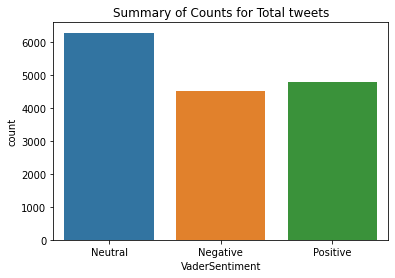

In [ ]:
sns.countplot(df["VaderSentiment"])
plt.title("Summary of Counts for Total tweets")

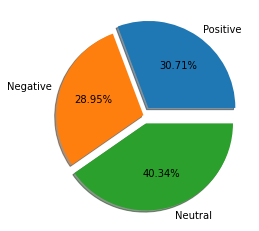

In [ ]:
# Piechart 

a=len(df[df["VaderSentiment"]=="Positive"])
b=len(df[df["VaderSentiment"]=="Negative"])
c=len(df[df["VaderSentiment"]=="Neutral"])
d=np.array([a,b,c])
explode = (0.1, 0.0, 0.1)
plt.pie(d,shadow=True,explode=explode,labels=["Positive","Negative","Neutral"],autopct='%1.2f%%');

In [ ]:
pip install flair

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     |████████████████████████████████| 401 kB 4.1 MB/s 
     |████████████████████████████████| 46 kB 3.9 MB/s 
     |████████████████████████████████| 19.7 MB 1.5 MB/s 
     |████████████████████████████████| 1.6 MB 47.3 MB/s 
     |████████████████████████████████| 4.7 MB 35.8 MB/s 
     |████████████████████████████████| 120 kB 38.3 MB/s 
     |████████████████████████████████| 1.2 MB 49.2 MB/s 
     |████████████████████████████████| 788 kB 41.1 MB/s 
     |████████████████████████████████| 53 kB 1.8 MB/s 
     |████████████████████████████████| 981 kB 45.1 MB/s 
     |████████████████████████████████| 200 kB 62.1 MB/s 
     |████████████████████████████████| 62 kB 1.4 MB/s 
     |████████████████████████████████| 6.6 MB 35.4 MB/s 
  Created wheel for mpld3: filename=mpld3-0.3-py3-none-any.whl size=116702 sha256=9990673b9dbb97301319c43b2b6dcb8778c5862ce1e37b3d37bff1e7ac7791d5
  Store

In [ ]:
# Function to analyze Sentiment using Flair

from flair.models import TextClassifier
from flair.data import Sentence
classifier = TextClassifier.load('en-sentiment')
def analyze_sentiment_flair(tweet):
    sentence = Sentence(tweet)
    classifier.predict(sentence)
    #if(sentence.labels[0].value == 'POSITIVE'):
    #    return 'Positive'
    #else:
    #    return 'Negative'
    return sentence.labels[0].value

2022-09-14 09:47:47,936 https://nlp.informatik.hu-berlin.de/resources/models/sentiment-curated-distilbert/sentiment-en-mix-distillbert_4.pt not found in cache, downloading to /tmp/tmpgh8wcx57


100%|██████████| 265512723/265512723 [00:29<00:00, 8915422.47B/s]

2022-09-14 09:48:18,570 copying /tmp/tmpgh8wcx57 to cache at /root/.flair/models/sentiment-en-mix-distillbert_4.pt


2022-09-14 09:48:19,329 removing temp file /tmp/tmpgh8wcx57
2022-09-14 09:48:19,392 loading file /root/.flair/models/sentiment-en-mix-distillbert_4.pt


In [ ]:
# Call function to get the Sentiments using Flair

df["FlairSentiment"] = df["CleanTweet"].apply(lambda x : analyze_sentiment_flair(x))
df.head(5)

,favorite_count,source,text,created_at,retweet_count,CleanTweet,Sentiment,TextBlobSentiment,VaderSentiment,FlairSentiment
0,1,Twitter for Android,"b""Don't believe it. https://t.co/VFfhPArn1a""",Sat Sep 03 04:09:04 +0000 2022,0,t believe it,Neutral,Neutral,Neutral,NEGATIVE
1,0,cmssocialservice,b'Surat records 11 new Covid-19 cases https://...,Sat Sep 03 04:06:03 +0000 2022,0,records 11 new covid 19 cases,Positive,Positive,Neutral,POSITIVE
2,38,TweetDeck,b'Hennepin County will no longer require COVID...,Sat Sep 03 04:09:00 +0000 2022,6,county will no longer require covid 19 vaccine...,Neutral,Neutral,Negative,POSITIVE
3,2,Twitter Web App,"b'As of Sept 1, the capital has given over 63....",Sat Sep 03 04:08:52 +0000 2022,0,of sept 1 the capital has given over 63 2 mill...,Neutral,Neutral,Neutral,NEGATIVE
4,1,Twitter for Android,b'@KushThrough @BlazedRTs @rtsmallstreams @Rts...,Sat Sep 03 04:15:46 +0000 2022,3,kushthrough ww nowplaying x lilroyce her ev,Neutral,Neutral,Neutral,POSITIVE


In [ ]:
df.to_csv("2022_Sep5_TextBlob-Vader-Flair-TweetSentimentDataset.csv",index=False)

In [ ]:
# Check Summary of Random Record for Flair
n = 15300
print("Original tweet:\n",df['text'][n])
print()
print("Clean tweet:\n",df['CleanTweet'][n])
print()
print("Sentiment of the tweet using Flair:\n",df['FlairSentiment'][n])

Original tweet:
 b'As I parooz Twitter tonight; I\xe2\x80\x99m concern for the individuals who\xe2\x80\x99ve lived through 32+months of a pandemic who are s\xe2\x80\xa6 https://t.co/k65oi8X8qd'

Clean tweet:
 i parooz twitter tonight i concern for the individuals who lived through 32 months of a pandemic who are s

Sentiment of the tweet using Flair:
 NEGATIVE


In [ ]:
# Overall Summary for Flair

print("Total Tweets Extracted Are {}".format(len(df.text)))
print("Total Positive Tweets are : {}".format(len(df[df["FlairSentiment"]=="POSITIVE"])))
print("Total Negative Tweets are : {}".format(len(df[df["FlairSentiment"]=="NEGATIVE"])))
print("Total Neutral Tweets are : {}".format(len(df[df["FlairSentiment"]=="NEUTRAL"])))

Total Tweets Extracted Are 15580
Total Positive Tweets are : 5773
Total Negative Tweets are : 9807
Total Neutral Tweets are : 0


In [ ]:
df["FlairSentiment"].value_counts()

NEGATIVE    9807
POSITIVE    5773
Name: FlairSentiment, dtype: int64

/usr/local/lib/python3.7/dist-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


Text(0.5, 1.0, 'Summary of Counts for Total tweets')

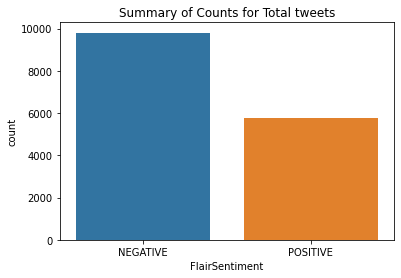

In [ ]:
sns.countplot(df["FlairSentiment"])
plt.title("Summary of Counts for Total tweets")

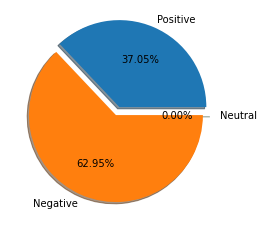

In [ ]:
# Piechart 
a=len(df[df["FlairSentiment"]=="POSITIVE"])
b=len(df[df["FlairSentiment"]=="NEGATIVE"])
c=len(df[df["FlairSentiment"]=="NEUTRAL"])
d=np.array([a,b,c])
explode = (0.1, 0.0, 0.1)
plt.pie(d,shadow=True,explode=explode,labels=["Positive","Negative","Neutral"],autopct='%1.2f%%');

There are 1304516 words in the combination of all review.


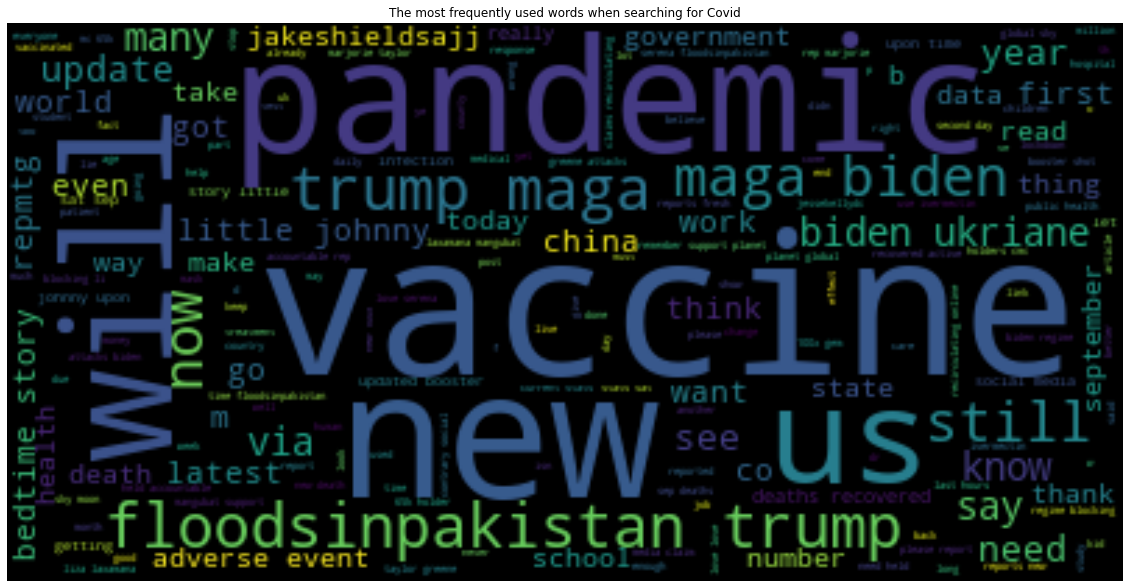

In [ ]:
# Combine all reviews into one big text and create a Cloud to see which Words are most common in these Tweets.

text = " ".join(review for review in df.CleanTweet)
print ("There are {} words in the combination of all review.".format(len(text)))


# Create stopword list:
stopwords = set(STOPWORDS)
Topic= "corona covid covid-19 covid19 coronavirus virus amp people case cases xe2 one don t re s c u xf0"
text_newALL = prepCloud(text,Topic)


# Generate a word cloud image
wordcloud = WordCloud(stopwords=stopwords,max_words=800,max_font_size=70).generate(text_newALL)

plt.figure(figsize=(20,20))
plt.imshow(wordcloud, interpolation='bilinear')
plt.title("The most frequently used words when searching for {}".format("Covid"),)
plt.axis("off")
plt.show()

There are 1304516 words in the combination of all review.


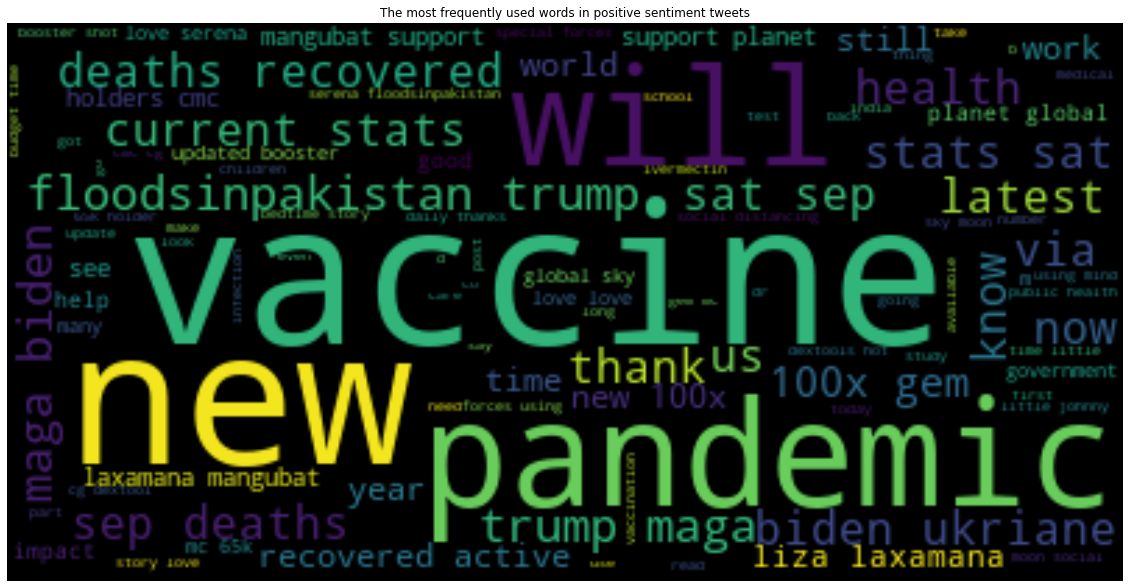

In [ ]:
# Combine POSITIVE reviews into one big text and create a Cloud to see which Words are most common in these Tweets.

text_positive = " ".join(review for review in df[df["FlairSentiment"]=="POSITIVE"].CleanTweet)
print ("There are {} words in the combination of all review.".format(len(text)))


# Create stopword list:
stopwords = set(STOPWORDS)
Topic= "corona covid covid-19 covid19 coronavirus virus amp people case cases xe2 one don t re s c u xf0"
text_new_positive = prepCloud(text_positive,Topic)


# Generate a word cloud image
wordcloud = WordCloud(stopwords=stopwords,max_words=800,max_font_size=70).generate(text_new_positive)

plt.figure(figsize=(20,20))
plt.imshow(wordcloud, interpolation='bilinear')
plt.title("The most frequently used words in positive sentiment tweets")
plt.axis("off")
plt.show()

There are 1304516 words in the combination of all review.


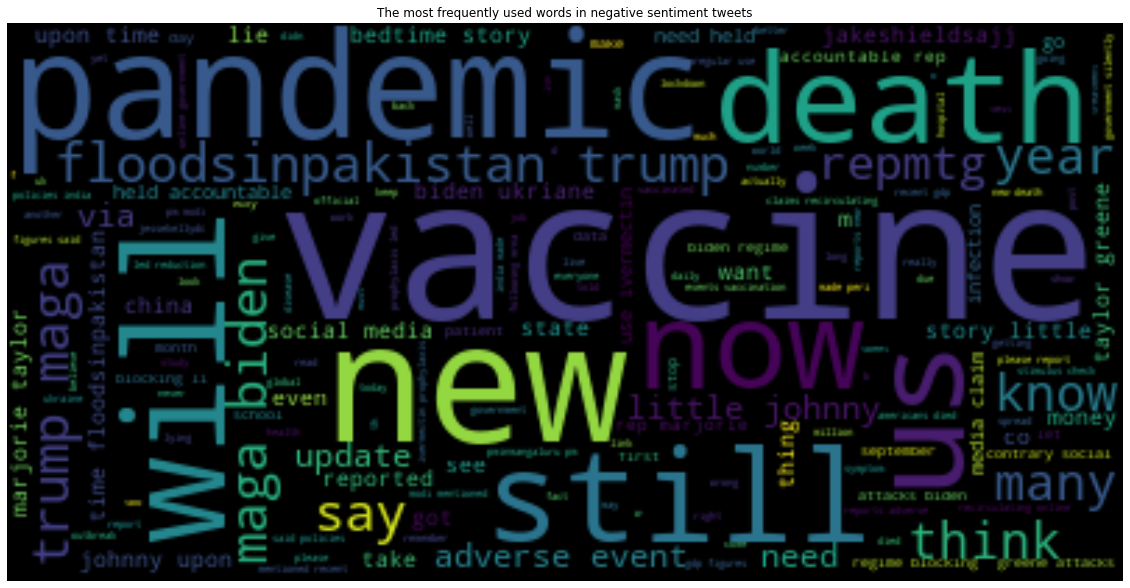

In [ ]:
# Combine Negative reviews into one big text and create a Cloud to see which Words are most common in these Tweets.

text_negative = " ".join(review for review in df[df["FlairSentiment"]=="NEGATIVE"].CleanTweet)
print ("There are {} words in the combination of all review.".format(len(text)))


# Create stopword list:
stopwords = set(STOPWORDS)
Topic= "corona covid covid-19 covid19 coronavirus virus amp people case cases xe2 one don t re s c u xf0"
text_new_negative = prepCloud(text_negative,Topic)

# Generate a word cloud image
wordcloud = WordCloud(stopwords=stopwords,max_words=800,max_font_size=70).generate(text_new_negative)

plt.figure(figsize=(20,20))
plt.imshow(wordcloud, interpolation='bilinear')
plt.title("The most frequently used words in negative sentiment tweets")
plt.axis("off")
plt.show()